# Rice Images Classification

In [34]:
import cv2
import pandas as pd 
from sklearn.model_selection import train_test_split
import numpy as np
import os
from keras.models import Sequential
from keras.layers import Conv2D,Dense,Flatten,Input,MaxPooling2D,Dropout,BatchNormalization,Reshape
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import VGG16, MobileNetV2

In [2]:
import warnings
warnings.filterwarnings("ignore")

## Exploraty Data Analysis and Data Preprocessing

In [3]:
labels=["Arborio","Basmati","Ipsala","Jasmine","Karacadag"]
img_path="Rice_Image_Dataset/"

In [4]:
img_list=[]
label_list=[]
for label in labels:
    for img_file in os.listdir(img_path+label):
        img_list.append(os.path.join(img_path,label,img_file))
        label_list.append(label)

In [5]:
df=pd.DataFrame({"img":img_list,"label":label_list})

In [6]:
df

,img,label
0,Rice_Image_Dataset/Arborio\Arborio (1).jpg,Arborio
1,Rice_Image_Dataset/Arborio\Arborio (10).jpg,Arborio
2,Rice_Image_Dataset/Arborio\Arborio (100).jpg,Arborio
3,Rice_Image_Dataset/Arborio\Arborio (1000).jpg,Arborio
4,Rice_Image_Dataset/Arborio\Arborio (10000).jpg,Arborio
...,...,...
74995,Rice_Image_Dataset/Karacadag\Karacadag (9995).jpg,Karacadag
74996,Rice_Image_Dataset/Karacadag\Karacadag (9996).jpg,Karacadag
74997,Rice_Image_Dataset/Karacadag\Karacadag (9997).jpg,Karacadag
74998,Rice_Image_Dataset/Karacadag\Karacadag (9998).jpg,Karacadag


In [7]:
img_path = "Rice_Image_Dataset/"

In [8]:
tf.keras.backend.clear_session()
train_ds = tf.keras.utils.image_dataset_from_directory(
    img_path,
    validation_split=0.2,       
    subset="training",
    seed=123,
    image_size=(128, 128),     
    batch_size=64
)


Found 75000 files belonging to 5 classes.
Using 60000 files for training.


In [9]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    img_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128,128),
    batch_size=64
)

Found 75000 files belonging to 5 classes.
Using 15000 files for validation.


In [10]:
normalization_layer = layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Model Training and Testing

In [11]:
num_classes = 5

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(train_ds,validation_data=val_ds,epochs=5,verbose=1)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 503s 490ms/step - accuracy: 0.7666 - loss: 0.5533 - val_accuracy: 0.9471 - val_loss: 0.1706
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 446s 475ms/step - accuracy: 0.9274 - loss: 0.1994 - val_accuracy: 0.9553 - val_loss: 0.1191
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 488s 460ms/step - accuracy: 0.9608 - loss: 0.1132 - val_accuracy: 0.9869 - val_loss: 0.0452
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 454s 484ms/step - accuracy: 0.9759 - loss: 0.0722 - val_accuracy: 0.9901 - val_loss: 0.0301
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 478s 459ms/step - accuracy: 0.9814 - loss: 0.0579 - val_accuracy: 0.9912 - val_loss: 0.0263


## Data Visualization

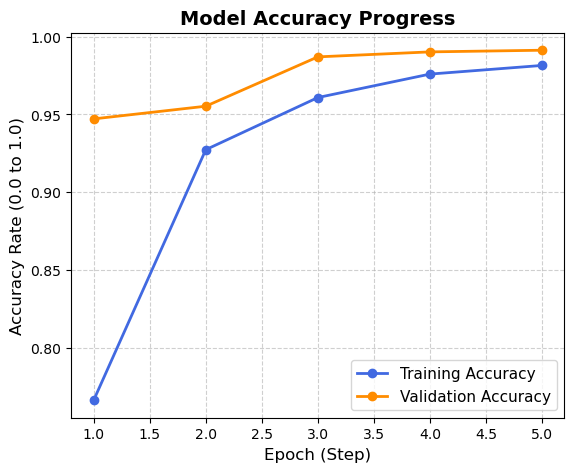

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', color='royalblue', linewidth=2, label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'o-', color='darkorange', linewidth=2, label='Validation Accuracy')
plt.title('Model Accuracy Progress', fontsize=14, fontweight='bold')
plt.xlabel('Epoch (Step)', fontsize=12)
plt.ylabel('Accuracy Rate (0.0 to 1.0)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

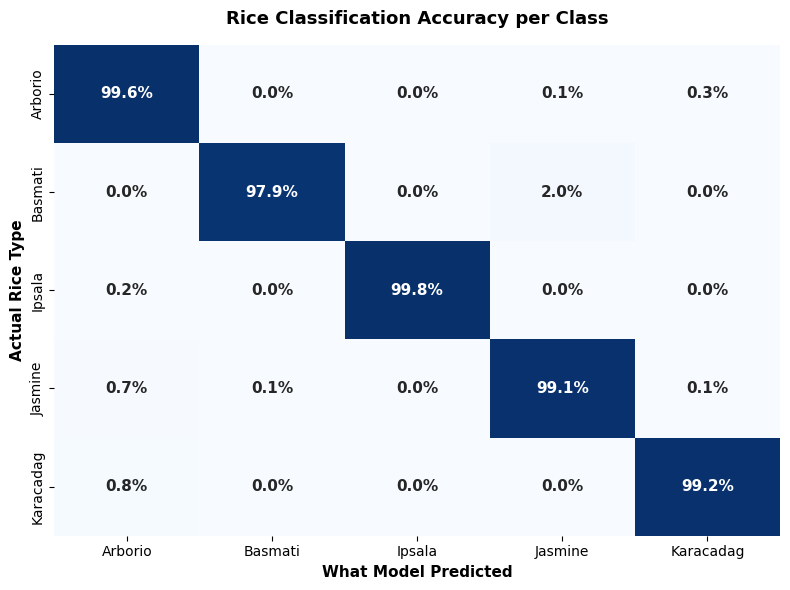

In [15]:
class_names = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

y_true = np.concatenate([y for x, y in val_ds], axis=0)
predictions = model.predict(val_ds, verbose=0)
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='.1%',           
    cmap='Blues', 
    cbar=False,
    xticklabels=class_names, 
    yticklabels=class_names,
    annot_kws={"size": 11, "weight": "bold"}
)

plt.title('Rice Classification Accuracy per Class', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('What Model Predicted', fontsize=11, fontweight='bold')
plt.ylabel('Actual Rice Type', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
model.save("rice_model.keras")

# Transfer Learning

In [30]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [33]:
from tensorflow.keras.applications import MobileNetV2

num_classes = 5
img_shape = (128, 128, 3)

base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=img_shape
)
base_model.trainable = False 

model_tl = models.Sequential([
    layers.Rescaling(1./255, input_shape=img_shape),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),  
    layers.Dense(num_classes, activation='softmax')
])

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 785s 721ms/step - accuracy: 0.9759 - loss: 0.0761 - val_accuracy: 0.9886 - val_loss: 0.0330
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 683s 728ms/step - accuracy: 0.9882 - loss: 0.0369 - val_accuracy: 0.9895 - val_loss: 0.0316
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 690s 736ms/step - accuracy: 0.9905 - loss: 0.0311 - val_accuracy: 0.9923 - val_loss: 0.0244
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 745s 738ms/step - accuracy: 0.9913 - loss: 0.0273 - val_accuracy: 0.9919 - val_loss: 0.0268
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 690s 735ms/step - accuracy: 0.9916 - loss: 0.0272 - val_accuracy: 0.9930 - val_loss: 0.0229
